# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

The used car dealership wants to understand what drives used car prices so it can optimize its inventory and pricing. This is a supervised regression problem where the goal is to predict the price of a used car based on the vehicle attributes such as year, model, mileage, condition, fuel type, transmission and other features as predictors. These features data have to be analyzed inorder to build regression models to determine which features have strongest relationship to price.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

I will examine the dataset by reviewing its size, features, datatypes, and summary statistics. 

Will also check for missing values, duplicate records, unusual values. 

Analyze the relationship between price and other features such as manufacturer, model, condition, fuel type, transmission. 

In [26]:
import pandas as pd
vehicles = pd.read_csv('vehicles.csv')

In [27]:
vehicles.head()


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [28]:
vehicles.shape

(426880, 18)

In [29]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

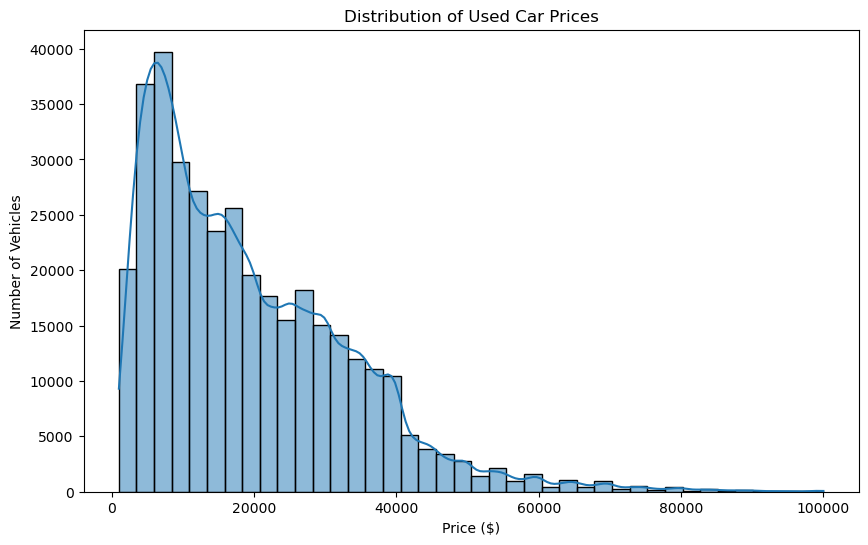

In [76]:
### Exploratory Data Analysis and Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(cars['price'], bins=40, kde=True)

plt.title('Distribution of Used Car Prices')
plt.xlabel('Price ($)')
plt.ylabel('Number of Vehicles')

plt.show()

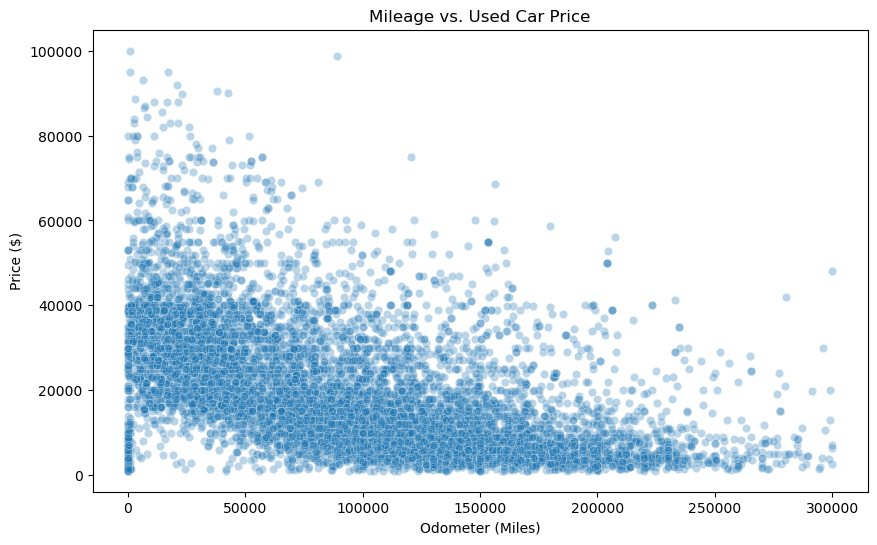

In [77]:
# Sample the data to make the scatter plot easier to read
plot_sample = cars.sample(n=10000, random_state=42)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_sample,
    x='odometer',
    y='price',
    alpha=0.3
)

plt.title('Mileage vs. Used Car Price')
plt.xlabel('Odometer (Miles)')
plt.ylabel('Price ($)')

plt.show()

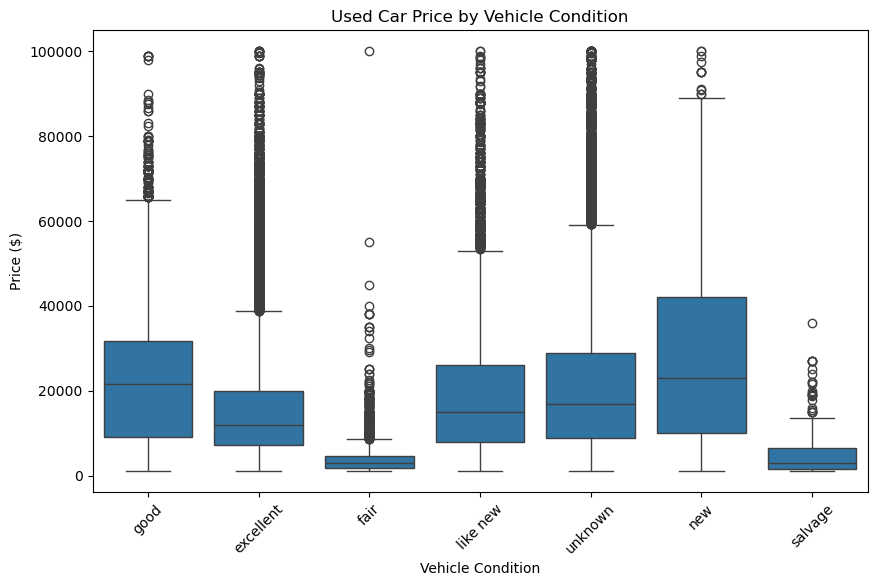

In [78]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=cars,
    x='condition',
    y='price'
)

plt.title('Used Car Price by Vehicle Condition')
plt.xlabel('Vehicle Condition')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)

plt.show()

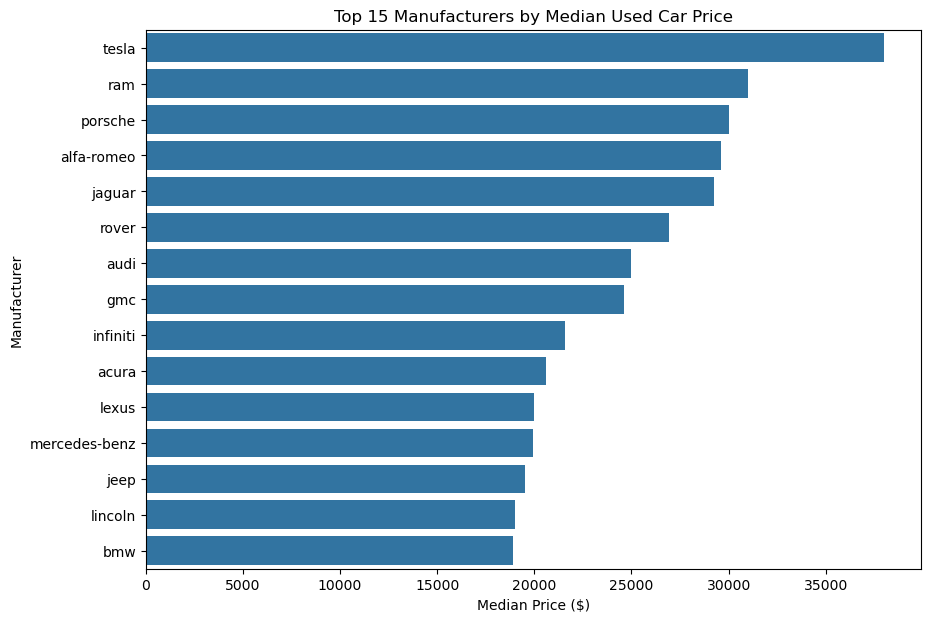

In [79]:
# Keep manufacturers with at least 500 vehicles
manufacturer_counts = cars['manufacturer'].value_counts()

common_manufacturers = manufacturer_counts[
    manufacturer_counts >= 500
].index

manufacturer_prices = (
    cars[cars['manufacturer'].isin(common_manufacturers)]
    .groupby('manufacturer')['price']
    .median()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=manufacturer_prices.values,
    y=manufacturer_prices.index
)

plt.title('Top 15 Manufacturers by Median Used Car Price')
plt.xlabel('Median Price ($)')
plt.ylabel('Manufacturer')

plt.show()

In [30]:
vehicles.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [31]:
vehicles.duplicated().sum()

np.int64(0)

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

The dataset needs to be cleaned before building regression models. I will remove unnecessary columns, handle missing values, filter unrealistic prices and mileage, and prepare categorical and numerical features for modeling. These steps will help reduce noise in the data and allow the machine learning models to work properly.

In [32]:
vehicles.isnull().sum()

id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

In [33]:
cars = vehicles.copy() #created a copy of the original dataset

In [34]:
cars = cars.drop(columns = ['id', 'VIN', 'size']) #dropping columns that have unique values & dont contribute to predicting price, & most missing values

In [35]:
cars.shape

(426880, 15)

In [36]:
cars.isnull().sum().sort_values(ascending=False)

cylinders       177678
condition       174104
drive           130567
paint_color     130203
type             92858
manufacturer     17646
title_status      8242
model             5277
odometer          4400
fuel              3013
transmission      2556
year              1205
region               0
price                0
state                0
dtype: int64

In [37]:
cars = cars.dropna(subset=['odometer', 'year'])

In [38]:
categorical_columns = cars.select_dtypes(include='object').columns #select non numeric columns
cars[categorical_columns] = cars[categorical_columns].fillna('unknown') #fill the na values by unknown
cars.isnull().sum()

region          0
price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
paint_color     0
state           0
dtype: int64

In [39]:
#prices below $1k and above 100k are considered outliers and not included for data modelling
cars = cars[(cars['price'] >=1000) & (cars['price']<= 100000)]

In [40]:
#odometer values greater than 300000 are eliminated
cars = cars[(cars['odometer']>= 0) & (cars['odometer']<= 300000)]

In [41]:
#limit the car make from 1990 to 2022
cars = cars[(cars['year']>= 1990) & (cars['year']<= 2022)]


In [42]:
cars.describe()

,price,year,odometer
count,362841.000000,362841.000000,362841.000000
mean,19440.631927,2012.309403,92762.727297
std,14247.063532,5.785620,61873.306373
min,1000.000000,1990.000000,0.000000
25%,7995.000000,2009.000000,38940.000000
50%,15995.000000,2013.000000,88317.000000
75%,27992.000000,2017.000000,136000.000000
max,100000.000000,2022.000000,300000.000000


In [43]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 362841 entries, 27 to 426879
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        362841 non-null  object 
 1   price         362841 non-null  int64  
 2   year          362841 non-null  float64
 3   manufacturer  362841 non-null  object 
 4   model         362841 non-null  object 
 5   condition     362841 non-null  object 
 6   cylinders     362841 non-null  object 
 7   fuel          362841 non-null  object 
 8   odometer      362841 non-null  float64
 9   title_status  362841 non-null  object 
 10  transmission  362841 non-null  object 
 11  drive         362841 non-null  object 
 12  type          362841 non-null  object 
 13  paint_color   362841 non-null  object 
 14  state         362841 non-null  object 
dtypes: float64(2), int64(1), object(12)
memory usage: 44.3+ MB


In [44]:
cars.shape

(362841, 15)

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

The goal is to predict used car prices using vehicle characteristics. I will compare different regression models and use cross-validation to evaluate their performance.

In [45]:
features = ['year', 'odometer', 'manufacturer', 'condition', 'fuel', 'transmission', 'drive', 'type']
X = cars[features]
y = cars['price']

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [47]:
# divide the features to numeric and categorical 
numeric_features = ['year', 'odometer']
categorical_features = ['manufacturer', 'condition', 'fuel', 'transmission', 'drive', 'type']

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown= 'ignore'), categorical_features)
    ])

In [52]:
# Linear Regression model
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
     ])

In [53]:
# Train the linear regression model
linear_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [54]:
#predict prices for test data
linear_predictions = linear_model.predict(X_test)

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, linear_predictions)
rmse = mean_squared_error(y_test, linear_predictions) ** 0.5
r2 = r2_score(y_test, linear_predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 5642.521925151641
RMSE: 8022.456010997279
R²: 0.6805808385098435


In [57]:
# build the ridge model
from sklearn.linear_model import Ridge
ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

In [58]:
# train the ridge model
ridge_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [59]:
# make predictions from ridge model:
ridge_predictions = ridge_model.predict(X_test)

In [60]:
# evaluate ridge model:
ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_rmse = mean_squared_error(y_test, ridge_predictions) ** 0.5
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge MAE:", ridge_mae)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R²:", ridge_r2)

Ridge MAE: 5642.592296167738
Ridge RMSE: 8022.165253063079
Ridge R²: 0.6806039915124653


In [61]:
# build lasso pipeline
from sklearn.linear_model import Lasso

lasso_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=10000))
])

In [62]:
lasso_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
lasso_predictions = lasso_model.predict(X_test)

In [64]:
lasso_mae = mean_absolute_error(y_test, lasso_predictions)
lasso_rmse = mean_squared_error(y_test, lasso_predictions) ** 0.5
lasso_r2 = r2_score(y_test, lasso_predictions)

print("Lasso MAE:", lasso_mae)
print("Lasso RMSE:", lasso_rmse)
print("Lasso R²:", lasso_r2)

Lasso MAE: 5642.442771757754
Lasso RMSE: 8024.153115528717
Lasso R²: 0.6804456816343376


In [67]:
# cros validation all 3 models:
from sklearn.model_selection import cross_val_score

linear_cv = -cross_val_score(
    linear_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
).mean()

ridge_cv = -cross_val_score(
    ridge_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
).mean()

lasso_cv = -cross_val_score(
    lasso_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
).mean()

print("Linear CV MAE:", linear_cv)
print("Ridge CV MAE:", ridge_cv)
print("Lasso CV MAE:", lasso_cv)

Linear CV MAE: 5668.637542428378
Ridge CV MAE: 5668.945287149001
Lasso CV MAE: 5669.073787638369


In [68]:
# Grid search cv:
from sklearn.model_selection import GridSearchCV

ridge_param_grid = {
    'model__alpha': [0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_model,
    ridge_param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge Alpha:", ridge_grid.best_params_)
print("Best Ridge CV MAE:", -ridge_grid.best_score_)

Best Ridge Alpha: {'model__alpha': 0.1}
Best Ridge CV MAE: 5668.751022259189


In [69]:
lasso_param_grid = {
    'model__alpha': [0.1, 1, 10, 100]
}

lasso_grid = GridSearchCV(
    lasso_model,
    lasso_param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print("Best Lasso Alpha:", lasso_grid.best_params_)
print("Best Lasso CV MAE:", -lasso_grid.best_score_)

Best Lasso Alpha: {'model__alpha': 0.1}
Best Lasso CV MAE: 5668.555539065035


In [71]:
# table for models comparison:
model_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Tuned Ridge',
        'Tuned Lasso'
    ],
    
    'CV MAE': [
        linear_cv,
        ridge_cv,
        lasso_cv,
        -ridge_grid.best_score_,
        -lasso_grid.best_score_
    ]
})

model_results

,Model,CV MAE
0,Linear Regression,5668.637542
1,Ridge Regression,5668.945287
2,Lasso Regression,5669.073788
3,Tuned Ridge,5668.751022
4,Tuned Lasso,5668.555539


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

The models were evaluated primarily using Mean Absolute Error (MAE) because it represents the average prediction error in dollars, making it easy to interpret for a used car dealership.

The Linear Regression, Ridge Regression, and Lasso Regression models produced very similar results. After 5-fold cross-validation, all three models had an MAE of approximately $5,669. Hyperparameter tuning was also performed for Ridge and Lasso using GridSearchCV, but tuning resulted in only very small changes in performance.

Overall, the models showed similar predictive performance, suggesting that regularization did not substantially improve prediction accuracy for this dataset.

In [72]:
best_lasso = lasso_grid.best_estimator_

In [73]:
feature_names = best_lasso.named_steps['preprocessor'].get_feature_names_out()

coefficients = best_lasso.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df.head()

,Feature,Coefficient
0,num__year,5645.474767
1,num__odometer,-4541.377630
2,cat__manufacturer_acura,1715.140092
3,cat__manufacturer_alfa-romeo,2576.268199
4,cat__manufacturer_aston-martin,22038.941203


In [74]:
# Largest positive coefficients
top_positive = coef_df.sort_values(
    'Coefficient',
    ascending=False
).head(10)

top_positive

,Feature,Coefficient
12,cat__manufacturer_ferrari,54813.254788
4,cat__manufacturer_aston-martin,22038.941203
39,cat__manufacturer_tesla,16897.077276
51,cat__fuel_diesel,15198.258978
34,cat__manufacturer_porsche,12413.017065
36,cat__manufacturer_rover,6484.952601
0,num__year,5645.474767
24,cat__manufacturer_lexus,4694.225537
48,cat__condition_new,4592.422884
61,cat__drive_4wd,4364.175934


In [75]:
# Largest negative coefficients
top_negative = coef_df.sort_values(
    'Coefficient'
).head(10)

top_negative

,Feature,Coefficient
13,cat__manufacturer_fiat,-9052.029871
30,cat__manufacturer_mitsubishi,-7467.676718
16,cat__manufacturer_harley-davidson,-6435.868058
66,cat__type_bus,-5508.000229
22,cat__manufacturer_kia,-5321.321717
49,cat__condition_salvage,-5013.571925
18,cat__manufacturer_hyundai,-4957.742312
69,cat__type_hatchback,-4810.628029
1,num__odometer,-4541.377630
42,cat__manufacturer_volkswagen,-4437.750964



The models showed that several vehicle characteristics are strongly associated with used car prices. Newer vehicles and vehicles with lower mileage tend to have higher predicted prices. Luxury and performance manufacturers such as Ferrari, Aston Martin, Porsche, and Lexus also showed strong positive associations with price. Tesla and Rover were also associated with higher predicted prices.

Other characteristics associated with higher prices included new condition, diesel fuel, and 4WD. On the other hand, higher mileage and salvage condition were associated with lower predicted prices. Hatchbacks and buses also showed negative price associations, along with several manufacturers including Fiat, Mitsubishi, Kia, Hyundai, and Volkswagen.

Overall, the results suggest that vehicle age, mileage, manufacturer, condition, fuel type, drivetrain, and vehicle type all contribute to used car pricing.

In [ ]:
### Coefficient Interpretation
Positive coefficients indicate characteristics associated with higher predicted prices,
while negative coefficients indicate characteristics associated with lower predicted prices, 
holding the other model variables constant.

Because year and odometer were standardized before modeling, their coefficients represent 
changes based on their standardized values rather than the effect of one individual year or mile. 
The categorical coefficients are best interpreted as indicators of positive or negative price
associations within the model rather than exact standalone price premiums.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

### Report to the Used Car Dealership

The goal of this analysis was to identify the vehicle characteristics that are most closely associated with used car prices so the dealership can make better inventory and pricing decisions.

### Primary Findings

The analysis found that newer vehicles and vehicles with lower mileage were generally associated with higher prices. Vehicle condition was also important, with vehicles in new condition associated with higher prices and salvage vehicles associated with lower prices.

Manufacturer also had a strong relationship with price. Luxury and performance manufacturers such as Ferrari, Aston Martin, Porsche, and Lexus showed strong positive price associations. Tesla and Rover were also associated with higher prices. Other characteristics associated with higher prices included diesel fuel and 4WD.

Higher mileage was associated with lower vehicle prices. Salvage condition also showed a strong negative relationship with price. Certain vehicle types, such as hatchbacks and buses, were associated with lower prices in this dataset.

### Recommendations

Based on these findings, the dealership should consider vehicle age, mileage, condition, manufacturer, fuel type, drivetrain, and vehicle type when deciding which vehicles to purchase and how to price them.

Newer, lower-mileage vehicles in better condition may be more valuable inventory opportunities. The dealership should be more cautious when purchasing high-mileage or salvage vehicles and should account for their lower expected market value when determining purchase prices.

The pricing model had an average prediction error of approximately $5,600, so it should be used as a supporting tool rather than as the only factor in pricing decisions. Future analysis could include specific vehicle models, geographic location, accident history, number of previous owners, and local market demand to improve pricing estimates.